# Superstore Sales Analysis

#### Industry level end-to-end Data Analyst project.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('super.csv')

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
,Index: 9789 entries, 0 to 9799
,Data columns (total 19 columns):
, #   Column          Non-Null Count  Dtype         
,---  ------          --------------  -----         
, 0   Row ID          9789 non-null   int64         
, 1   Order ID        9789 non-null   object        
, 2   Order Date      9789 non-null   datetime64[ns]
, 3   Ship Date       9789 non-null   object        
, 4   Ship Mode       9789 non-null   object        
, 5   Customer ID     9789 non-null   object        
, 6   Customer Name   9789 non-null   object        
, 7   Segment         9789 non-null   object        
, 8   Country         9789 non-null   object        
, 9   City            9789 non-null   object        
, 10  State           9789 non-null   object        
, 11  Postal Code     9789 non-null   float64       
, 12  Region          9789 non-null   object        
, 13  Product ID      9789 non-null   object        
, 14  Category        9789 non-null   object    

# Data inspection using head(), info(), and shape()

In [5]:
df.shape

(9800, 18)

In [36]:
df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order_Date_Key
0,1,CA-2017-152156,2017-11-08,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,20171108
1,2,CA-2017-152156,2017-11-08,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,20171108
2,3,CA-2017-138688,2017-06-12,16-06-2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,20170612
3,4,US-2016-108966,2016-10-11,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,20161011
4,5,US-2016-108966,2016-10-11,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,20161011
5,6,CA-2015-115812,2015-06-09,14-06-2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,20150609
6,7,CA-2015-115812,2015-06-09,14-06-2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,20150609
7,8,CA-2015-115812,2015-06-09,14-06-2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,20150609
8,9,CA-2015-115812,2015-06-09,14-06-2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,20150609
9,10,CA-2015-115812,2015-06-09,14-06-2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,20150609


In [7]:
df.tail(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
9790,9791,CA-2018-144491,27-03-2018,01-04-2018,Standard Class,CJ-12010,Caroline Jumper,Consumer,United States,Houston,Texas,77070.0,Central,FUR-CH-10001714,Furniture,Chairs,"Global Leather & Oak Executive Chair, Burgundy",211.246
9791,9792,CA-2015-127166,21-05-2015,23-05-2015,Second Class,KH-16360,Katherine Hughes,Consumer,United States,Houston,Texas,77070.0,Central,OFF-EN-10003134,Office Supplies,Envelopes,Staple envelope,56.064
9792,9793,CA-2015-127166,21-05-2015,23-05-2015,Second Class,KH-16360,Katherine Hughes,Consumer,United States,Houston,Texas,77070.0,Central,FUR-CH-10003396,Furniture,Chairs,Global Deluxe Steno Chair,107.772
9793,9794,CA-2015-127166,21-05-2015,23-05-2015,Second Class,KH-16360,Katherine Hughes,Consumer,United States,Houston,Texas,77070.0,Central,OFF-PA-10001560,Office Supplies,Paper,"Adams Telephone Message Books, 5 1/4” x 11”",4.832
9794,9795,CA-2015-127166,21-05-2015,23-05-2015,Second Class,KH-16360,Katherine Hughes,Consumer,United States,Houston,Texas,77070.0,Central,OFF-BI-10000977,Office Supplies,Binders,Ibico Plastic Spiral Binding Combs,18.240
9795,9796,CA-2017-125920,21-05-2017,28-05-2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.798
9796,9797,CA-2016-128608,12-01-2016,17-01-2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.368
9797,9798,CA-2016-128608,12-01-2016,17-01-2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.188
9798,9799,CA-2016-128608,12-01-2016,17-01-2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.376
9799,9800,CA-2016-128608,12-01-2016,17-01-2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-AC-10000487,Technology,Accessories,SanDisk Cruzer 4 GB USB Flash Drive,10.384


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 9800 entries, 0 to 9799
,Data columns (total 18 columns):
, #   Column         Non-Null Count  Dtype  
,---  ------         --------------  -----  
, 0   Row ID         9800 non-null   int64  
, 1   Order ID       9800 non-null   object 
, 2   Order Date     9800 non-null   object 
, 3   Ship Date      9800 non-null   object 
, 4   Ship Mode      9800 non-null   object 
, 5   Customer ID    9800 non-null   object 
, 6   Customer Name  9800 non-null   object 
, 7   Segment        9800 non-null   object 
, 8   Country        9800 non-null   object 
, 9   City           9800 non-null   object 
, 10  State          9800 non-null   object 
, 11  Postal Code    9789 non-null   float64
, 12  Region         9800 non-null   object 
, 13  Product ID     9800 non-null   object 
, 14  Category       9800 non-null   object 
, 15  Sub-Category   9800 non-null   object 
, 16  Product Name   9800 non-null   object 
, 17  Sales          9800 non-null  

#
“First, I performed initial data inspection using head(), info(), and shape()”

# Data Cleaning

In [10]:
# So here, I want to check null value
# It is very important in data cleaning, to check null values.

pd.isnull(df)   # It shows null value in the form of true and false 

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9796,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9797,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9798,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [72]:
## Missing values check.

# check for null values

pd.isnull(df).sum()   # it shows null value directly in the form of number  

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Order_Date_Key    0
Month             0
Year              0
dtype: int64

In [71]:
## Handle missing values.

# Drop null values
df.dropna(inplace=True)   # It is used for removing null value 

In [42]:
## To check date using Date format.

df['Order Date'] = pd.to_datetime(df['Order Date'])

In [73]:
df['Order Date'].dtypes # It shows datatype of column.

dtype('<M8[ns]')

In [44]:
# Change data type.
df['Order Date'] = df['Order Date'].astype('int') # it is use for change column data type 

In [45]:
# Here, python was assuming my "Order Date" column as datatype "object"
# So, i changed the data type into "integer"

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Order_Date_Key'] = df['Order Date'].dt.strftime('%Y%m%d').astype(int)

In [47]:
df['Order_Date_Key'].dtypes

dtype('int64')

In [48]:
# It is used for rename the column.

df.rename(columns= {'Row ID' : 'ROW'})

,ROW,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order_Date_Key
0,1,CA-2017-152156,2017-11-08,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,20171108
1,2,CA-2017-152156,2017-11-08,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,20171108
2,3,CA-2017-138688,2017-06-12,16-06-2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,20170612
3,4,US-2016-108966,2016-10-11,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,20161011
4,5,US-2016-108966,2016-10-11,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,20161011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,2017-05-21,28-05-2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980,20170521
9796,9797,CA-2016-128608,2016-01-12,17-01-2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680,20160112
9797,9798,CA-2016-128608,2016-01-12,17-01-2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880,20160112
9798,9799,CA-2016-128608,2016-01-12,17-01-2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760,20160112


# 
“I handled missing values and converted date columns into proper datetime format.”

# Feature Engineering

In [54]:
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [55]:
# Month & Year column.

df['Month'] = df['Ship Date'].dt.month
df['Year'] = df['Ship Date'].dt.year

In [56]:
print(df['Ship Date'].dtype)

datetime64[ns]


# Exploratory Data Analysis (EDA)

In [61]:
# 1. Total Sales.

total_sales = df['Sales'].sum()
total_sales

np.float64(2252607.4127)

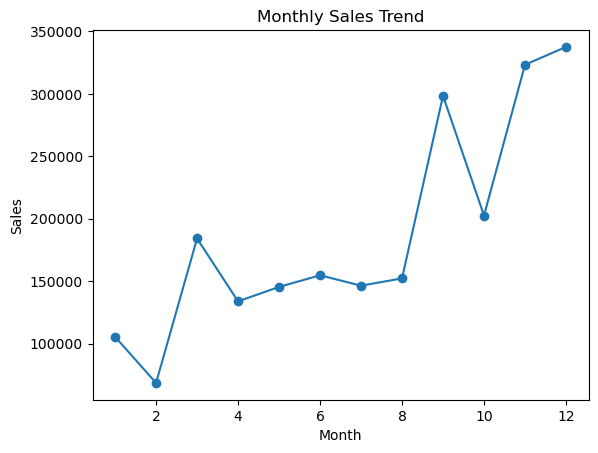

In [62]:
# 2. Monthly Sales Trend.

monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

#
1. Sales remain moderate in the first half of the year, with a noticeable dip in February followed by gradual recovery till June.

2. A sharp growth occurs in the last quarter, especially in September and November–December, indicating strong seasonal or festive demand.

3. December records the highest sales overall, showing that year-end periods contribute the most revenue and should be targeted for marketing and promotions.

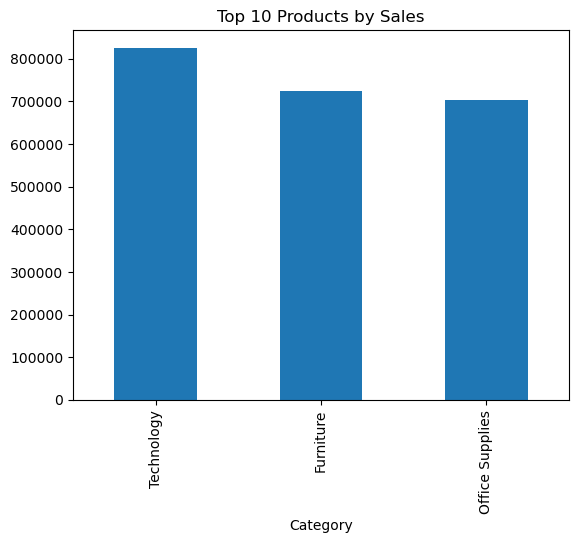

In [67]:
# 3. Top 3 Products.

top_products = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')
plt.title("Top 10 Products by Sales")
plt.show()


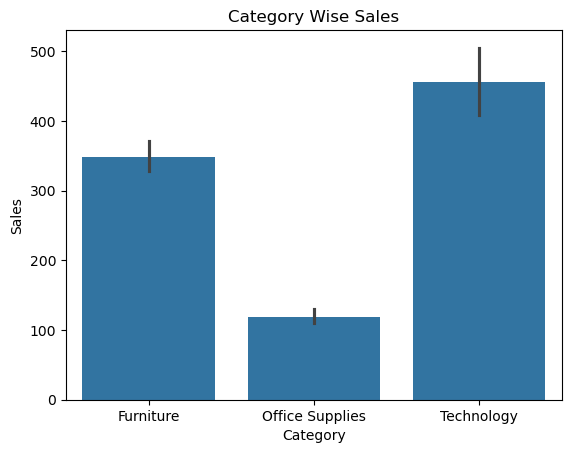

In [69]:
# Category-wise Sales.

sns.barplot(x=df['Category'], y=df['Sales'])
plt.title("Category Wise Sales")
plt.show()


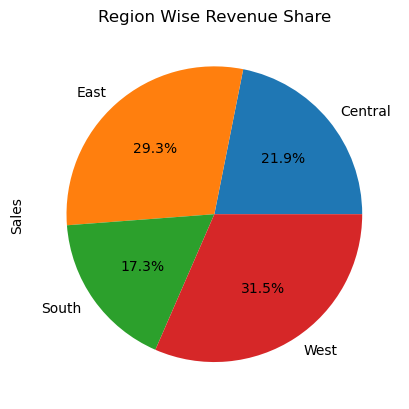

In [70]:
# Region-wise Analysis.

region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Region Wise Sales Share")
plt.show()
